# Energy-Based OOD Detection: CIFAR-10 (ID) vs SVHN (OOD)

Notebook này là phần **Energy Score và đánh giá OOD/Unknown** cho project.

**Mục tiêu bàn giao**

1. Viết hàm tính Energy Score từ logits của model đã train trên CIFAR-10.
2. Chạy model trên **CIFAR-10 test** và **SVHN test**.
3. Vẽ histogram/boxplot phân phối energy.
4. Chọn threshold để phát hiện `Unknown`.
5. Xuất bảng kết quả ID/OOD: FPR95, AUROC, AUPR-In, Known/Unknown rate.

**Quy ước dùng trong notebook**

- Free energy: `E(x) = -T * logsumexp(logits / T)`.
- Negative energy: `S(x) = -E(x) = T * logsumexp(logits / T)`.
- `S(x)` càng lớn thì mẫu càng giống **in-distribution/CIFAR-10**.
- Dự đoán `Unknown/OOD` nếu `S(x) <= threshold`.

> Trong bài gốc của Liu et al., negative energy được dùng để thuận chiều với score truyền thống: mẫu ID có score cao hơn, OOD có score thấp hơn.

## 0. Cấu hình đường dẫn

Cách dùng nhanh:

- Nếu đã có `cifar10_test_logits.npy`, `cifar10_test_labels.npy`, và `svhn_test_logits.npy`, notebook sẽ đánh giá ngay.
- Nếu chưa có `svhn_test_logits.npy`, chạy phần **4. Sinh logits cho CIFAR-10/SVHN bằng checkpoint** để tạo logits từ `best_model.pth`.
- Nên chọn threshold bằng **CIFAR validation** nếu có logits validation. Nếu chưa có, notebook dùng CIFAR test để demo và cần ghi rõ trong báo cáo.

In [1]:
from pathlib import Path
import json
import math
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from sklearn.metrics import roc_auc_score, average_precision_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

# Sửa ROOT nếu chạy trên Colab/Drive.
# Nếu notebook nằm trong thư mục notebooks/, root project là thư mục cha
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

SEARCH_DIRS = [
    ROOT,
    ROOT / "output",
    ROOT / "output" / "cifar",
    ROOT / "output" / "svhn",
    Path("/mnt/data"),
    Path("/content"),
    Path("/content/drive/MyDrive"),
]

CIFAR_LOGITS_FILE = 'cifar10_test_logits.npy'
CIFAR_LABELS_FILE = 'cifar10_test_labels.npy'
SVHN_LOGITS_FILE = 'svhn_test_logits.npy'
MODEL_FILE = 'best_model.pth'

OUTPUT_DIR = ROOT / "output" / "ood"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TPR = 0.95
TEMPERATURE = 1.0
BATCH_SIZE = 256
NUM_WORKERS = 2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)


def find_file(filename, search_dirs=SEARCH_DIRS):
    for d in search_dirs:
        p = d / filename
        if p.exists():
            return p
    return None

print('OUTPUT_DIR =', OUTPUT_DIR.resolve())
print('CIFAR logits:', find_file(CIFAR_LOGITS_FILE))
print('CIFAR labels:', find_file(CIFAR_LABELS_FILE))
print('SVHN logits :', find_file(SVHN_LOGITS_FILE))
print('Checkpoint  :', find_file(MODEL_FILE))

OUTPUT_DIR = D:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood
CIFAR logits: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\cifar\cifar10_test_logits.npy
CIFAR labels: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\cifar\cifar10_test_labels.npy
SVHN logits : d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\svhn_test_logits.npy
Checkpoint  : d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\best_model.pth


## 1. Hàm Energy Score và threshold

Công thức triển khai ổn định số học:

\[
S(x) = -E(x) = T \log \sum_{k=1}^{K} \exp(f_k(x)/T)
\]

Trong đó `f_k(x)` là logit của class `k`, `T=1` theo thiết lập mặc định của paper khi dùng energy score inference-time.

In [2]:
def stable_logsumexp_np(x, axis=1):
    x = np.asarray(x)
    m = np.max(x, axis=axis, keepdims=True)
    return np.squeeze(m, axis=axis) + np.log(np.sum(np.exp(x - m), axis=axis))


def negative_energy_np(logits, temperature=1.0):
    """S(x) = -E(x) = T * logsumexp(logits / T). Larger score => more ID-like."""
    logits = np.asarray(logits, dtype=np.float64)
    if temperature <= 0:
        raise ValueError('temperature must be positive')
    return temperature * stable_logsumexp_np(logits / temperature, axis=1)


def free_energy_np(logits, temperature=1.0):
    """E(x) = -T * logsumexp(logits / T). Lower energy => more ID-like."""
    return -negative_energy_np(logits, temperature)


def softmax_confidence_np(logits):
    logits = np.asarray(logits, dtype=np.float64)
    m = np.max(logits, axis=1, keepdims=True)
    e = np.exp(logits - m)
    p = e / np.sum(e, axis=1, keepdims=True)
    return np.max(p, axis=1)


def choose_threshold_from_id(id_scores, target_tpr=0.95):
    """Với score càng lớn càng ID, threshold = percentile 5% nếu target_tpr = 95%."""
    return float(np.percentile(id_scores, 100 * (1 - target_tpr)))


def predict_unknown(scores, threshold):
    """True nghĩa là mẫu bị gán Unknown/OOD."""
    return np.asarray(scores) <= threshold


def evaluate_ood(id_scores, ood_scores, threshold=None, target_tpr=0.95):
    id_scores = np.asarray(id_scores)
    ood_scores = np.asarray(ood_scores)
    if threshold is None:
        threshold = choose_threshold_from_id(id_scores, target_tpr=target_tpr)

    id_known = id_scores > threshold
    ood_known = ood_scores > threshold  # false positive: OOD nhưng vẫn bị nhận là Known/ID

    result = {
        'threshold_negative_energy': float(threshold),
        'ID_TPR_known_%': float(id_known.mean() * 100),
        'OOD_FPR95_%': float(ood_known.mean() * 100),
        'OOD_unknown_rate_%': float((~ood_known).mean() * 100),
        'Detector_accuracy_%': float((id_known.sum() + (~ood_known).sum()) / (len(id_scores) + len(ood_scores)) * 100),
        'N_ID': int(len(id_scores)),
        'N_OOD': int(len(ood_scores)),
    }

    if SKLEARN_OK:
        y_true = np.concatenate([np.ones(len(id_scores)), np.zeros(len(ood_scores))])  # ID = positive
        y_score = np.concatenate([id_scores, ood_scores])
        result['AUROC_%'] = float(roc_auc_score(y_true, y_score) * 100)
        result['AUPR_In_%'] = float(average_precision_score(y_true, y_score) * 100)
    return result


def describe_scores(name, scores):
    scores = np.asarray(scores)
    return {
        'set': name,
        'n': len(scores),
        'mean': float(scores.mean()),
        'std': float(scores.std()),
        'min': float(scores.min()),
        'p05': float(np.percentile(scores, 5)),
        'p25': float(np.percentile(scores, 25)),
        'median': float(np.percentile(scores, 50)),
        'p75': float(np.percentile(scores, 75)),
        'p95': float(np.percentile(scores, 95)),
        'max': float(scores.max()),
    }

## 2. Kiểm tra nhanh với logits CIFAR-10 đã có

Cell này dùng file `cifar10_test_logits.npy` và `cifar10_test_labels.npy` đã xuất từ mô hình baseline.

In [3]:
cifar_logits_path = find_file(CIFAR_LOGITS_FILE)
cifar_labels_path = find_file(CIFAR_LABELS_FILE)

if cifar_logits_path is None:
    raise FileNotFoundError(f'Không tìm thấy {CIFAR_LOGITS_FILE}. Hãy upload/copy file vào ROOT.')

cifar_logits = np.load(cifar_logits_path)
cifar_labels = np.load(cifar_labels_path) if cifar_labels_path is not None else None

cifar_neg_energy = negative_energy_np(cifar_logits, temperature=TEMPERATURE)
cifar_energy = free_energy_np(cifar_logits, temperature=TEMPERATURE)
cifar_confidence = softmax_confidence_np(cifar_logits)
cifar_pred = np.argmax(cifar_logits, axis=1)

print('CIFAR logits shape:', cifar_logits.shape)
if cifar_labels is not None:
    cifar_acc = np.mean(cifar_pred == cifar_labels)
    print(f'CIFAR-10 test accuracy từ logits: {cifar_acc*100:.2f}%')

threshold = choose_threshold_from_id(cifar_neg_energy, target_tpr=TARGET_TPR)
print(f'Threshold tau tại ID TPR={TARGET_TPR*100:.0f}%: {threshold:.6f}')
print('Quy tắc: nếu negative_energy <= tau thì gán Unknown/OOD')

pd.DataFrame([describe_scores('CIFAR-10 ID', cifar_neg_energy)])

CIFAR logits shape: (10000, 10)
CIFAR-10 test accuracy từ logits: 92.92%
Threshold tau tại ID TPR=95%: 4.813414
Quy tắc: nếu negative_energy <= tau thì gán Unknown/OOD


,set,n,mean,std,min,p05,p25,median,p75,p95,max
0,CIFAR-10 ID,10000,15.962023,6.928912,-1.213912,4.813414,10.774625,15.922075,20.97404,27.445982,39.028416


In [4]:
# Lưu bảng per-sample để demo/report.
cifar_score_df = pd.DataFrame({
    'sample_id': np.arange(len(cifar_logits)),
    'negative_energy': cifar_neg_energy,
    'free_energy': cifar_energy,
    'softmax_confidence': cifar_confidence,
    'pred': cifar_pred,
})
if cifar_labels is not None:
    cifar_score_df.insert(1, 'label', cifar_labels)
    cifar_score_df['correct'] = cifar_score_df['pred'] == cifar_score_df['label']

cifar_score_csv = OUTPUT_DIR / 'cifar10_test_energy_scores.csv'
cifar_score_df.to_csv(cifar_score_csv, index=False)
print('Saved:', cifar_score_csv)
cifar_score_df.head()

Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\cifar10_test_energy_scores.csv


,sample_id,label,negative_energy,free_energy,softmax_confidence,pred,correct
0,0,3,16.816833,-16.816833,1.000000,3,True
1,1,8,20.570955,-20.570955,1.000000,8,True
2,2,8,14.533252,-14.533252,0.999996,8,True
3,3,0,10.165969,-10.165969,0.999591,0,True
4,4,6,21.365650,-21.365650,1.000000,6,True


### Plot ID energy hiện có

Sau khi có SVHN logits, phần plot ID-vs-OOD ở mục 5 sẽ là hình chính đưa vào slide/báo cáo. Hình dưới chỉ kiểm tra phân phối CIFAR-10 ID và threshold.

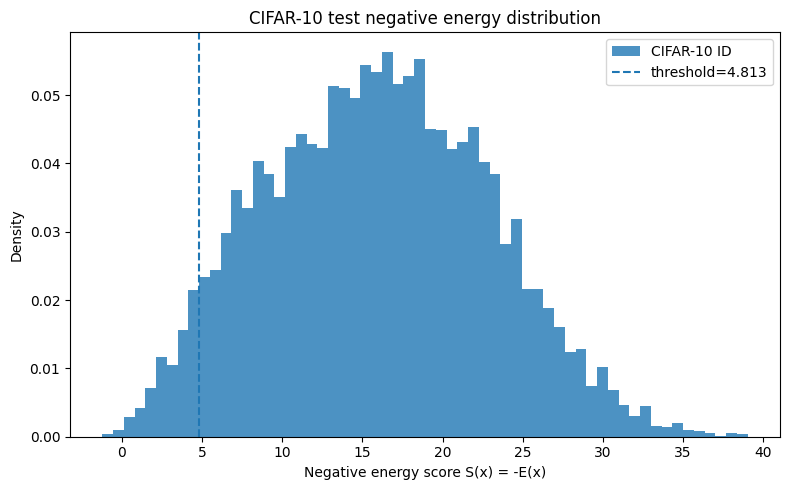

Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\cifar10_negative_energy_hist.png


C:\Users\ninhd\AppData\Local\Temp\ipykernel_39228\2478924415.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cifar_neg_energy], labels=['CIFAR-10 ID'])


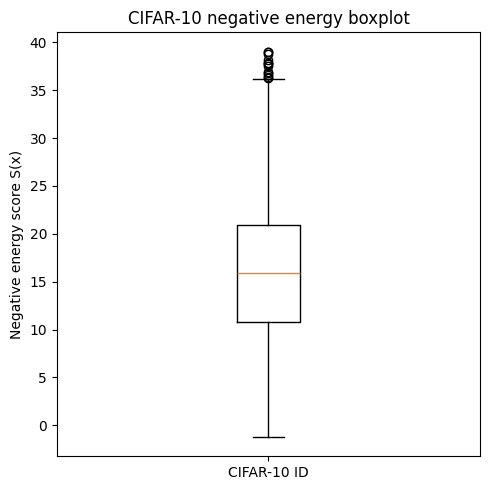

Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\cifar10_negative_energy_boxplot.png


In [5]:
plt.figure(figsize=(8, 5))
plt.hist(cifar_neg_energy, bins=60, alpha=0.8, density=True, label='CIFAR-10 ID')
plt.axvline(threshold, linestyle='--', label=f'threshold={threshold:.3f}')
plt.xlabel('Negative energy score S(x) = -E(x)')
plt.ylabel('Density')
plt.title('CIFAR-10 test negative energy distribution')
plt.legend()
plt.tight_layout()
fig_path = OUTPUT_DIR / 'cifar10_negative_energy_hist.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print('Saved:', fig_path)

plt.figure(figsize=(5, 5))
plt.boxplot([cifar_neg_energy], labels=['CIFAR-10 ID'])
plt.ylabel('Negative energy score S(x)')
plt.title('CIFAR-10 negative energy boxplot')
plt.tight_layout()
fig_path = OUTPUT_DIR / 'cifar10_negative_energy_boxplot.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print('Saved:', fig_path)

## 3. Định nghĩa model ResNet18-CIFAR để sinh SVHN logits nếu chưa có

Checkpoint `best_model.pth` có key dạng `conv1`, `bn1`, `layer1...layer4`, `fc`, tương ứng ResNet18 cho CIFAR-10 với `conv1` 3x3 và không dùng maxpool đầu vào.

**Lưu ý quan trọng về transform:** SVHN test phải dùng đúng preprocessing như lúc train CIFAR-10. Nếu train notebook dùng `Normalize(mean, std)`, giữ `NORMALIZATION = 'cifar'`. Nếu chỉ chia ảnh cho 255 như pipeline dữ liệu ban đầu, đặt `NORMALIZATION = 'none'`.

In [6]:
# Chạy cell này nếu cần sinh svhn_test_logits.npy từ checkpoint.
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.downsample = None
        if stride != 1 or in_planes != self.expansion * planes:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out = F.relu(out + identity)
        return out


class CifarResNet(nn.Module):
    def __init__(self, block=BasicBlock, layers=(2, 2, 2, 2), num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def load_checkpoint_model(model_path):
    model = CifarResNet(num_classes=10)
    ckpt = torch.load(model_path, map_location='cpu')
    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        ckpt = ckpt['state_dict']
    if isinstance(ckpt, dict) and any(k.startswith('module.') for k in ckpt.keys()):
        ckpt = {k.replace('module.', '', 1): v for k, v in ckpt.items()}
    missing, unexpected = model.load_state_dict(ckpt, strict=False)
    print('Missing keys:', missing)
    print('Unexpected keys:', unexpected)
    model.eval()
    return model

## 4. Sinh logits cho CIFAR-10 test và SVHN test bằng checkpoint

Chỉ cần chạy phần này nếu chưa có `svhn_test_logits.npy`.

Cell dùng `torchvision.datasets.CIFAR10` và `torchvision.datasets.SVHN`. Nếu đã có dữ liệu trong thư mục local, đặt `download=False`; nếu chạy trên Colab có mạng, để `download=True`.

In [7]:
# Bỏ comment và chạy nếu cần sinh logits.
# import torchvision
# import torchvision.transforms as transforms
# from torchvision import datasets
# from torch.utils.data import DataLoader
#
# DATA_ROOT = ROOT / 'data'
# DATA_ROOT.mkdir(parents=True, exist_ok=True)
#
# NORMALIZATION = 'cifar'  # 'cifar' hoặc 'none'
# DOWNLOAD = True          # Colab: True; nếu đã có data local: False
#
# if NORMALIZATION == 'cifar':
#     transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
#     ])
# elif NORMALIZATION == 'none':
#     transform = transforms.ToTensor()
# else:
#     raise ValueError('NORMALIZATION phải là cifar hoặc none')
#
# cifar_test = datasets.CIFAR10(root=str(DATA_ROOT), train=False, download=DOWNLOAD, transform=transform)
# svhn_test = datasets.SVHN(root=str(DATA_ROOT), split='test', download=DOWNLOAD, transform=transform)
#
# cifar_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
# svhn_loader = DataLoader(svhn_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
#
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model_path = find_file(MODEL_FILE)
# if model_path is None:
#     raise FileNotFoundError('Không tìm thấy best_model.pth')
# model = load_checkpoint_model(model_path).to(device)
#
# @torch.no_grad()
# def collect_logits(model, loader, device):
#     all_logits, all_labels = [], []
#     for x, y in loader:
#         x = x.to(device)
#         logits = model(x).detach().cpu().numpy()
#         all_logits.append(logits)
#         all_labels.append(np.asarray(y))
#     return np.concatenate(all_logits), np.concatenate(all_labels)
#
# # Sinh logits. Có thể bỏ CIFAR nếu đã có file CIFAR logits từ baseline.
# gen_cifar_logits, gen_cifar_labels = collect_logits(model, cifar_loader, device)
# gen_svhn_logits, gen_svhn_labels = collect_logits(model, svhn_loader, device)
#
# np.save(OUTPUT_DIR / 'cifar10_test_logits_generated.npy', gen_cifar_logits)
# np.save(OUTPUT_DIR / 'cifar10_test_labels_generated.npy', gen_cifar_labels)
# np.save(OUTPUT_DIR / 'svhn_test_logits.npy', gen_svhn_logits)
# np.save(OUTPUT_DIR / 'svhn_test_labels.npy', gen_svhn_labels)
#
# print('Generated CIFAR logits:', gen_cifar_logits.shape)
# print('Generated SVHN logits :', gen_svhn_logits.shape)
# print('Saved to:', OUTPUT_DIR)
#
# # Sanity check: nếu dùng cùng transform/architecture với baseline, CIFAR accuracy phải xấp xỉ kết quả baseline.
# print('Generated CIFAR accuracy:', (gen_cifar_logits.argmax(axis=1) == gen_cifar_labels).mean() * 100)

## 5. Đánh giá OOD: CIFAR-10 test vs SVHN test

Sau khi có `svhn_test_logits.npy`, chạy cell này để có threshold cuối, bảng kết quả, histogram và boxplot ID/OOD.

In [8]:
svhn_logits_path = find_file(SVHN_LOGITS_FILE, search_dirs=[OUTPUT_DIR] + SEARCH_DIRS)

if svhn_logits_path is None:
    print('Chưa có svhn_test_logits.npy. Hãy chạy mục 4 để sinh logits, hoặc copy file vào OUTPUT_DIR/ROOT.')
else:
    svhn_logits = np.load(svhn_logits_path)
    svhn_neg_energy = negative_energy_np(svhn_logits, temperature=TEMPERATURE)
    svhn_energy = free_energy_np(svhn_logits, temperature=TEMPERATURE)
    svhn_confidence = softmax_confidence_np(svhn_logits)

    threshold = choose_threshold_from_id(cifar_neg_energy, target_tpr=TARGET_TPR)
    result = evaluate_ood(cifar_neg_energy, svhn_neg_energy, threshold=threshold, target_tpr=TARGET_TPR)

    result_df = pd.DataFrame([result]).T.rename(columns={0: 'value'})
    result_csv = OUTPUT_DIR / 'ood_results_cifar10_vs_svhn.csv'
    result_df.to_csv(result_csv)

    summary_df = pd.DataFrame([
        describe_scores('CIFAR-10 ID', cifar_neg_energy),
        describe_scores('SVHN OOD', svhn_neg_energy),
    ])
    summary_csv = OUTPUT_DIR / 'energy_summary_cifar10_vs_svhn.csv'
    summary_df.to_csv(summary_csv, index=False)

    print('Threshold tau:', threshold)
    print('Saved:', result_csv)
    print('Saved:', summary_csv)
    display(result_df)
    display(summary_df)

Threshold tau: 4.813413864815168
Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\ood_results_cifar10_vs_svhn.csv
Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\energy_summary_cifar10_vs_svhn.csv


,value
threshold_negative_energy,4.813414
ID_TPR_known_%,95.000000
OOD_FPR95_%,77.523817
OOD_unknown_rate_%,22.476183
Detector_accuracy_%,42.603797
N_ID,10000.000000
N_OOD,26032.000000
AUROC_%,84.215448
AUPR_In_%,78.981228


,set,n,mean,std,min,p05,p25,median,p75,p95,max
0,CIFAR-10 ID,10000,15.962023,6.928912,-1.213912,4.813414,10.774625,15.922075,20.974040,27.445982,39.028416
1,SVHN OOD,26032,7.840409,3.593446,-1.535565,2.647822,5.058642,7.389161,10.499561,14.176150,24.280083


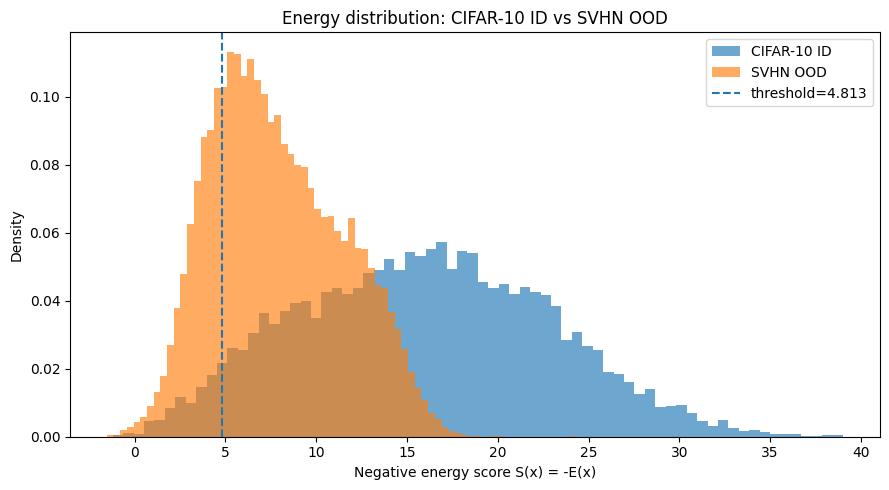

Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\energy_hist_cifar10_vs_svhn.png


C:\Users\ninhd\AppData\Local\Temp\ipykernel_39228\3731968452.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cifar_neg_energy, svhn_neg_energy], labels=['CIFAR-10 ID', 'SVHN OOD'])


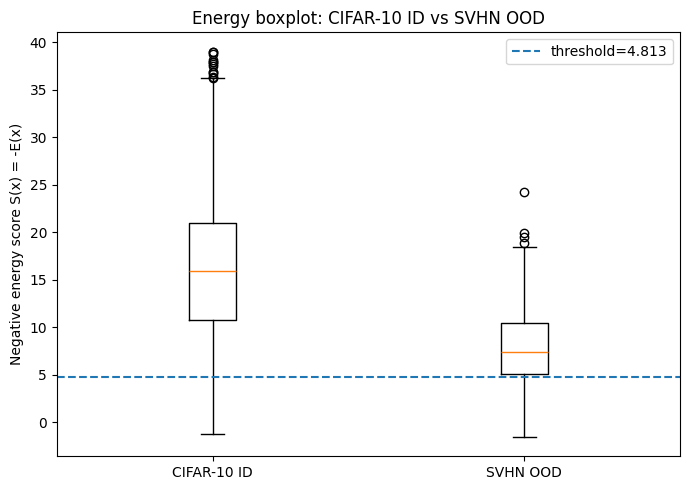

Saved: d:\OneDrive\ThS\Phat-trien-tri-tue-nhan-tao-dang-tin-cay\project\github\IT5416_08\output\ood\energy_boxplot_cifar10_vs_svhn.png


In [9]:
if 'svhn_logits_path' in globals() and svhn_logits_path is not None:
    plt.figure(figsize=(9, 5))
    plt.hist(cifar_neg_energy, bins=70, alpha=0.65, density=True, label='CIFAR-10 ID')
    plt.hist(svhn_neg_energy, bins=70, alpha=0.65, density=True, label='SVHN OOD')
    plt.axvline(threshold, linestyle='--', label=f'threshold={threshold:.3f}')
    plt.xlabel('Negative energy score S(x) = -E(x)')
    plt.ylabel('Density')
    plt.title('Energy distribution: CIFAR-10 ID vs SVHN OOD')
    plt.legend()
    plt.tight_layout()
    hist_path = OUTPUT_DIR / 'energy_hist_cifar10_vs_svhn.png'
    plt.savefig(hist_path, dpi=200)
    plt.show()
    print('Saved:', hist_path)

    plt.figure(figsize=(7, 5))
    plt.boxplot([cifar_neg_energy, svhn_neg_energy], labels=['CIFAR-10 ID', 'SVHN OOD'])
    plt.axhline(threshold, linestyle='--', label=f'threshold={threshold:.3f}')
    plt.ylabel('Negative energy score S(x) = -E(x)')
    plt.title('Energy boxplot: CIFAR-10 ID vs SVHN OOD')
    plt.legend()
    plt.tight_layout()
    box_path = OUTPUT_DIR / 'energy_boxplot_cifar10_vs_svhn.png'
    plt.savefig(box_path, dpi=200)
    plt.show()
    print('Saved:', box_path)

## 6. Demo hàm inference Known/Unknown

Cell này minh họa đầu ra cần ghép vào demo cuối. Với một batch logits, hệ thống trả về:

- class dự đoán trong 10 class CIFAR-10;
- negative energy score;
- trạng thái `Known` hoặc `Unknown`.

In [10]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


def predict_with_unknown(logits, threshold, class_names=CIFAR10_CLASSES, temperature=1.0):
    logits = np.asarray(logits)
    scores = negative_energy_np(logits, temperature=temperature)
    preds = logits.argmax(axis=1)
    rows = []
    for i, (pred, score) in enumerate(zip(preds, scores)):
        is_unknown = score <= threshold
        rows.append({
            'sample_id': i,
            'pred_class': 'Unknown' if is_unknown else class_names[int(pred)],
            'raw_pred_class': class_names[int(pred)],
            'negative_energy': float(score),
            'threshold': float(threshold),
            'status': 'Unknown/OOD' if is_unknown else 'Known/ID',
        })
    return pd.DataFrame(rows)

# Demo 10 mẫu CIFAR đầu tiên.
predict_with_unknown(cifar_logits[:10], threshold)

,sample_id,pred_class,raw_pred_class,negative_energy,threshold,status
0,0,cat,cat,16.816833,4.813414,Known/ID
1,1,ship,ship,20.570955,4.813414,Known/ID
2,2,ship,ship,14.533252,4.813414,Known/ID
3,3,airplane,airplane,10.165969,4.813414,Known/ID
4,4,frog,frog,21.365650,4.813414,Known/ID
5,5,frog,frog,17.068459,4.813414,Known/ID
6,6,automobile,automobile,11.508187,4.813414,Known/ID
7,7,frog,frog,16.073248,4.813414,Known/ID
8,8,cat,cat,16.411566,4.813414,Known/ID
9,9,automobile,automobile,17.031142,4.813414,Known/ID
